<a href="https://colab.research.google.com/github/pushpakgaidhane294/NNDL_lab/blob/main/Practical5_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

In [ ]:
(train_ds, validation_ds), dataset_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.920CFG_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
class_names = dataset_info.features['label'].names

print("Flower Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Flower Classes:
0 : dandelion
1 : daisy
2 : tulips
3 : sunflowers
4 : roses


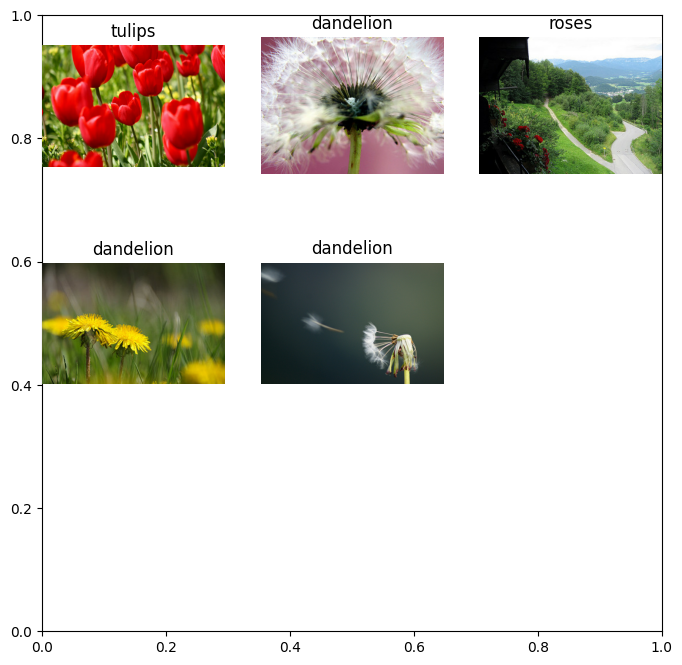

In [ ]:
plt.figure(figsize=(8, 8))

for image, label in train_ds.take(9):
    plt.subplot(3, 3, len(plt.gca().images) + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.show()

In [ ]:
IMG_SIZE = (160, 160)

train_ds = train_ds.map(
    lambda x, y: (
        tf.image.resize(x, IMG_SIZE) / 255.0,
        y
    )
)

validation_ds = validation_ds.map(
    lambda x, y: (
        tf.image.resize(x, IMG_SIZE) / 255.0,
        y
    )
)

In [ ]:
BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE)
validation_ds = validation_ds.batch(BATCH_SIZE)

In [ ]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 5

# Compile the model before training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7694 - loss: 0.6251 - val_accuracy: 0.8665 - val_loss: 0.3653
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 716ms/step - accuracy: 0.8920 - loss: 0.3065 - val_accuracy: 0.8774 - val_loss: 0.3282
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 810ms/step - accuracy: 0.9210 - loss: 0.2185 - val_accuracy: 0.8896 - val_loss: 0.3144
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 804ms/step - accuracy: 0.9499 - loss: 0.1587 - val_accuracy: 0.8883 - val_loss: 0.3312
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 723ms/step - accuracy: 0.9567 - loss: 0.1247 - val_accuracy: 0.8896 - val_loss: 0.3596


In [ ]:
loss, accuracy = model.evaluate(validation_ds)

print("--------------------------------")
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("--------------------------------")

print(
    "Accuracy Percentage:",
    accuracy * 100,
    "%"
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 568ms/step - accuracy: 0.8896 - loss: 0.3596
--------------------------------
Validation Loss: 0.35963985323905945
Validation Accuracy: 0.8896457552909851
--------------------------------
Accuracy Percentage: 88.96457552909851 %


In [ ]:
for images, labels in validation_ds.take(1):

    predictions = model.predict(images)

    predicted_class = np.argmax(predictions[0])
    actual_class = labels[0].numpy()

    print("--------------------------------")
    print("Predicted:", class_names[predicted_class])
    print("Actual:", class_names[actual_class])
    print("--------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
--------------------------------
Predicted: roses
Actual: roses
--------------------------------


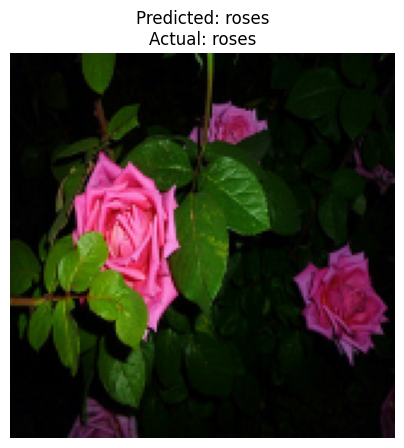

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(images[0])

plt.title(
    "Predicted: " +
    class_names[predicted_class] +
    "\nActual: " +
    class_names[actual_class]
)

plt.axis("off")
plt.show()

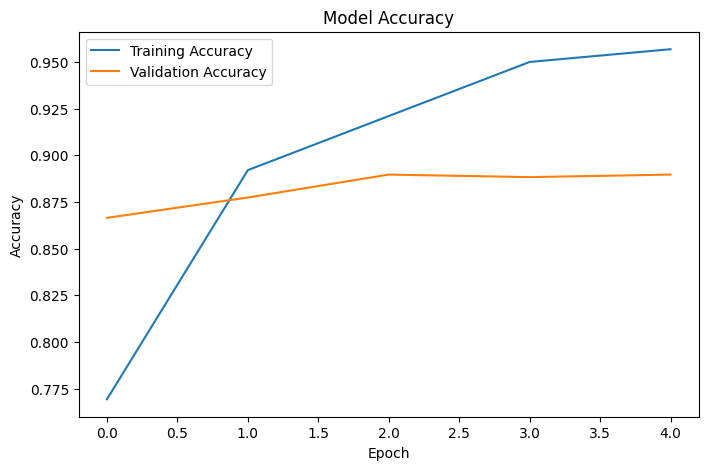

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

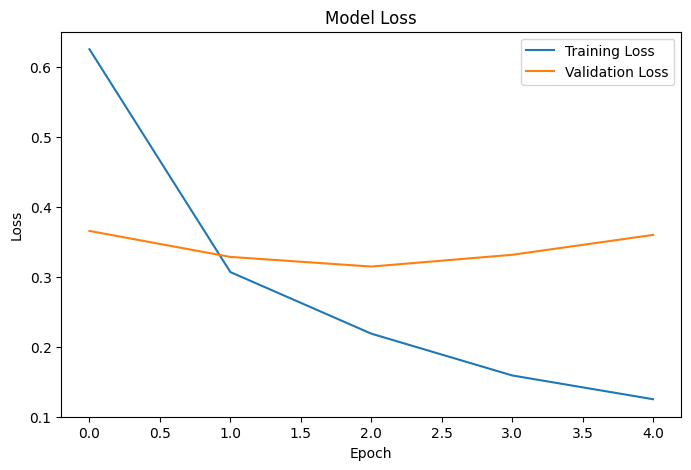

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
print("\n========================================")
print("TRANSFER LEARNING EXPERIMENT COMPLETED")
print("========================================")

print("Dataset       : TensorFlow Flowers")
print("Model         : MobileNetV2")
print("Image Size    : 160 x 160")
print("Batch Size    :", BATCH_SIZE)
print("Epochs        :", EPOCHS)
print("Classes       :", len(class_names))
print("Accuracy      :", round(accuracy * 100, 2), "%")

print("========================================")


TRANSFER LEARNING EXPERIMENT COMPLETED
Dataset       : TensorFlow Flowers
Model         : MobileNetV2
Image Size    : 160 x 160
Batch Size    : 32
Epochs        : 5
Classes       : 5
Accuracy      : 88.96 %
